## 2D CSA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
np.random.seed(1)

### Data Simulation 
simulating the data according to different classes

In [3]:
def simulate_class_data(n, ratio_A, ratio_B, ratio_C, ratio_D):
    """
    Simulates 4 scenarios of class data
        - Class A: P1 is good and P2 is bad
        - Class B: P1 is bad and P2 is good 
        - Class C: Both P1 and P2 are good
        - Class D: Both P1 and P2 are bad

    scores = 1-p (so 0.1 is good and 0.8 is bad)
    """

    # Class A: P1 is good (0.1) and P2 is bad (0.7)
    n_A = int(n * ratio_A)
    A = np.abs(np.random.multivariate_normal([0.1, 0.7], [[0.01, 0], [0, 0.01]], n_A))

    # Class B: P1 is bad (0.7) and P2 is good (0.1)
    n_B = int(n * ratio_B)
    B = np.abs(np.random.multivariate_normal([0.7, 0.1], [[0.01, 0], [0, 0.01]], n_B))  

    # Class C: Both P1 and P2 are good (0.1)
    n_C = int(n * ratio_C)
    C = np.abs(np.random.multivariate_normal([0.1, 0.1], [[0.01, 0], [0, 0.01]], n_C))  

    # Class D: Both P1 and P2 are bad (0.7)
    n_D = int(n * ratio_D)
    D = np.abs(np.random.multivariate_normal([0.7, 0.7], [[0.01, 0], [0, 0.01]], n_D))  

    # Combining all the classes into one dataset
    all_scores = np.vstack((A, B, C, D))
    all_scores = np.clip(all_scores, 0, 1)  # Clipping to make sure that all scores are between 0 and 1

    # Returning the scores and labels
    labels = np.array(['A']*n_A + ['B']*n_B + ['C']*n_C + ['D']*n_D)
    return all_scores, labels

### Phage-Wise Data Splitting 

In [4]:
def split_calibration_data(scores, labels, split_ratio):
    """
    Splits the calibration data into two sets based on the split ratio.
    """
 
    n = len(scores)      
    indices = np.arange(n)     
    np.random.shuffle(indices)  

    limit = int(n * split_ratio)     # Number of samples for the shape set
    shape_set = scores[indices[:limit]]
    shape_set_labels = labels[indices[:limit]]
    size_set = scores[indices[limit:]]
    size_set_labels = labels[indices[limit:]]
    
    return shape_set, size_set, shape_set_labels, size_set_labels

### Discovering the Shape

**$\pi / 2$ --> $2 \pi$???** 

In [5]:
def shape_discovery(shape_set_scores, alpha, M):
    """ 
    Determines the shape of the envelope that cover 1- alpha of the shape set
    Its is convex - inersection of the half planes
    
    """
    # Generating M directions (Angles 0 to 90 degrees)
    angles = np.linspace(0, np.pi/2, M)
    u_directions = np.vstack([np.cos(angles), np.sin(angles)]).T

    # Projecting the scores from the 'shape' sets onto the M directions
    projections = shape_set_scores @ u_directions.T
    
    # We are searcging for the largest beta such that the intersection of half-planes defined by the quantiles has coverage >= 1-alpha
    # We will search from small beta (wide region) to large beta (tight region)
    beta_candidates = np.linspace(alpha/M, alpha, 500)
    
    beta_star = alpha/M     # Default to conservative Bonferroni
    q_tilde = np.quantile(projections, 1 - beta_star, axis=0)

    for beta in beta_candidates:
        # getting individual 1-beta quantile for all the directions
        q_beta = np.quantile(projections, 1 - beta, axis=0)
        
        inside = np.all(projections <= q_beta, axis=1)   # checking if the point is inside all the directional boundaries
        coverage = np.mean(inside)

        if coverage >= 1 - alpha:    # Checking if the coverage condition is satisfied
            # if coverage holds we update the beta star (we want the largest beta that gives us the 1-alpha coverage)
            beta_star = beta  
            q_tilde = q_beta
        else:
            break 

    return u_directions, q_tilde, beta_star

### Scaling

In [6]:
def size_scaling(size_set_scores, size_set_labels, u_directions, q_tilde, alpha):
    """ 
    Adjusts the shape (zooms in or out) using the size set (independent of the shape set) to get the 1-alpha coverage
    calculates a unique scaling factor for each class of host
    """

    # projecting the scores onto the M directions
    projections = size_set_scores @ u_directions.T

    # calculating tau (the scaling factot needed to touch each point with our shape)
    tau_scores = np.max(projections / (q_tilde + 1e-12), axis=1)

    t_hats = {}
    unique_class = np.unique(size_set_labels)

    for cls in unique_class:
        # filtering the taus that belong only to the current class
        mask = (size_set_labels == cls)
        class_taus = tau_scores[mask]

        # applying the finite-sample quantile lemma to this specific class
        n_cls = len(class_taus)
        sorted_tau = np.sort(class_taus) 

        idx = int(np.ceil((n_cls + 1) * (1 - alpha))) - 1   # ensures that the 1-alpha guarantee holds exactly for finite data sets

        # t_hat is the final scale factor (tau value at that specific index)
        t_hats[cls] = sorted_tau[np.clip(idx, 0, n_cls - 1)]
    return t_hats, tau_scores

## Testing Function 
getting the prediction set

In [7]:
def get_prediction_set(candidate_host_scores, u_directions, q_tilde, t_hats):
    """
    Tests each candidate host against its class specific threshold. 
    Returns indices of those accepted.
    We accept the host if its score falls inside the scaled envelope
    """
    # projecting the candidate hosts (how the phage looks like against potential hosts)
    projs = candidate_host_scores @ u_directions.T

    # calculating the ratio relative to the shape set
    ratios = np.max(projs / (q_tilde + 1e-12), axis=1)

    accepted_indices = []
    host_names = ['A', 'B', 'C', 'D']

    for i, ratio in enumerate(ratios):
        threshold = t_hats[host_names[i]] if isinstance(t_hats, dict) else t_hats
        if ratio <= threshold:
            accepted_indices.append(i) 

    #if the ratio is <=t_hat then the point is inside the 1-alpha envelope, so we return all the hosts that satisfy this condition
    return np.array(accepted_indices)

### Visualizing

In [8]:
def plot_4_host_inference(raw_scores, labels, u_directions, q_tilde, t_hats, new_scores, accepted_indices, alpha):
    plt.figure(figsize=(10, 8))
    
    # Plotting the 4 clusters of data 
    colors = {'A': 'tab:cyan', 'B': 'tab:orange', 'C': 'tab:green', 'D': 'tab:purple'}
    for cls in ['A', 'B', 'C', 'D']:
        mask = labels == cls
        plt.scatter(raw_scores[mask, 0], raw_scores[mask, 1], c=colors[cls], label=f"Host {cls}", s=20)

    # Plotting the four different envelopes
    x_range = np.linspace(0, 1, 150)
    y_range = np.linspace(0, 1, 150)
    X, Y = np.meshgrid(x_range, y_range)
    grid = np.vstack([X.ravel(), Y.ravel()]).T
    
    # drawing a boundary for each host based on its specific t_hats_dict
    for cls in ['A', 'B', 'C', 'D']:
        t_cls = t_hats[cls]
        q_final = q_tilde * t_cls
        # we project the grid to see where the safety zone for the current specific hostends
        inside = np.all((grid @ u_directions.T) <= q_final, axis = 1).reshape(X.shape)

        # drawning a line for this specific host class
        plt.contour(X, Y, inside, levels = [0.5], colors=colors[cls], linestyles = '--')
        

    # Plotting the scores for the new phage against each of the 4 candidate hosts
    host_names = ['Host A', 'Host B', 'Host C', 'Host D']
    for i, score in enumerate(new_scores):
        is_accepted = i in accepted_indices
        marker = 'X'
        color = 'darkblue' if is_accepted else 'red'
        
        plt.scatter(score[0], score[1], color=color, marker=marker, s=150, edgecolors='white', zorder=5)
        plt.text(score[0] + 0.02, score[1] + 0.02, f"Test: {host_names[i]}", 
                 fontweight='bold', fontsize=10)


    confidence_level = int((1 - alpha) * 100)
    plt.title(f"CSA 4-Host Inference\n(Blue Shaded Area = {confidence_level}% Confidence Set)")
    
    plt.xlabel("Model 1 Error (P1)")
    plt.ylabel("Model 2 Error (P2)")
    
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    handles.append(Line2D([0], [0], color='blue', lw=2))
    labels_legend.append("Acceptance Region")
    
    plt.legend(handles=handles, labels=labels_legend, loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.show()

In [9]:
def plot_4_host_inference_hist(raw_scores, labels, u_directions, q_tilde, t_hats, new_scores, accepted_indices, alpha):
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # creating the marginal axes
    divider = make_axes_locatable(ax)
    ax_hist_x = divider.append_axes("top", 1.2, pad=0.1, sharex=ax)
    ax_hist_y = divider.append_axes("right", 1.2, pad=0.1, sharey=ax)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # plotting the calibration data and the histograms
    colors = {'A': 'tab:cyan', 'B': 'tab:orange', 'C': 'tab:green', 'D': 'tab:purple'}
    host_classes = ['A', 'B', 'C', 'D']

    # tracking the max counts
    max_count_x = 0
    max_count_y = 0
    
    for cls in host_classes:
        mask = (labels == cls)
        scores_cls = raw_scores[mask]
        
        # main scatter plot
        ax.scatter(scores_cls[:, 0], scores_cls[:, 1], c=colors[cls], s=25, alpha=0.7, label=f"Host {cls}")
        
        # plotting the X axis histograms
        counts_x, bins_x, _ = ax_hist_x.hist(scores_cls[:, 0], bins=np.linspace(0, 1, 40), color=colors[cls], alpha=0.4, density=False, edgecolor = colors[cls], linewidth = 0.7)
        max_count_x = max(max_count_x, np.max(counts_x))
        
        # Plotting the Y axis histograms
        counts_y, bins_y, _ = ax_hist_y.hist(scores_cls[:, 1], bins=np.linspace(0, 1, 40), color=colors[cls], alpha=0.4, density=False, orientation='horizontal', edgecolor = colors[cls], linewidth = 0.7)
        max_count_y = max(max_count_y, np.max(counts_y))

    # labels and gridlines to show max counts
    ax_hist_x.set_ylabel("Count", fontsize = 8)
    ax_hist_y.set_xlabel("Count", fontsize = 8)
    ax_hist_x.grid(axis = 'y', linestyle = '--', alpha = 0.3)
    ax_hist_y.grid(axis = 'x', linestyle = '--', alpha = 0.3)

    # hiding the x axis lines for both the histograms
    ax_hist_x.tick_params(labelbottom=False)
    ax_hist_y.tick_params(labelleft=False)

    # plotting the class specific envelopes
    x_grid = np.linspace(0, 1, 150)
    y_grid = np.linspace(0, 1, 150)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.vstack([X.ravel(), Y.ravel()]).T
    
    for cls in host_classes:
        t_cls = t_hats[cls]
        q_final = q_tilde * t_cls
        inside = np.all((grid_points @ u_directions.T) <= q_final, axis=1).reshape(X.shape)
        ax.contour(X, Y, inside, levels=[0.5], colors=colors[cls], linestyles='--', linewidths=2)

    # plotting the new points
    host_names = ['Host A', 'Host B', 'Host C', 'Host D']
    for i, score in enumerate(new_scores):
        is_accepted = i in accepted_indices
        marker = 'X'
        color = 'blue' if is_accepted else 'red'
        
        ax.scatter(score[0], score[1], color=color, marker=marker, s=200, edgecolors='black', zorder=10)
        ax.text(score[0] + 0.02, score[1] + 0.02, f"Test: {host_names[i]}", fontweight='bold' if is_accepted else 'normal', 
                fontsize=11, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    
    ax.set_xlabel("Model 1 Error (P1)", fontsize=12)
    ax.set_ylabel("Model 2 Error (P2)", fontsize=12)
    ax.set_title(f"CSA 4-Hosts ({int((1-alpha)*100)}% Confidence)", fontsize=14, pad=20)
    
    confidence_level = int((1 - alpha) * 100)

    # legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Host {c}', markerfacecolor=colors[c], markersize=10) for c in host_classes]    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title= f'{confidence_level}% Class Boundaries', title_fontsize=12)             

    plt.show()

execution

In [10]:
np.random.seed(42)
alpha = 0.25
M = 100

# Setting up the scores
raw_scores, labels = simulate_class_data(n=400, ratio_A=0.35, ratio_B=0.35, ratio_C=0.15, ratio_D=0.15)
S1, S2, L1, L2 = split_calibration_data(raw_scores, labels, 0.5)

# finding the envelope (shape discover + size adjustment)
u_dirs, q_template, b_star = shape_discovery(S1, alpha, M)
t_hats_dict, _ = size_scaling(S2, L2, u_dirs, q_template, alpha)

print("Class specific thresholds(t):")
for cls, val in t_hats_dict.items():
    print(f"Host {cls}: {val: .3f}")

# Testing a new phage whose TRUE host is B
# We generate scores for how this phage looks against the 4 possible hosts
new_phage_test_scores = np.array([
    [0.75, 0.75], # Against Host A (P1 good (should give a bad score), P2 bad)
    [0.65, 0.10], # Against Host B (THE TRUTH - P1 bad, P2 good (should give a good score))
    [0.70, 0.87], # Against Host C (Both good)
    [0.65, 0.65]  # Against Host D (Both bad)
])

Class specific thresholds(t):
Host A:  0.969
Host B:  0.980
Host C:  0.302
Host D:  1.074


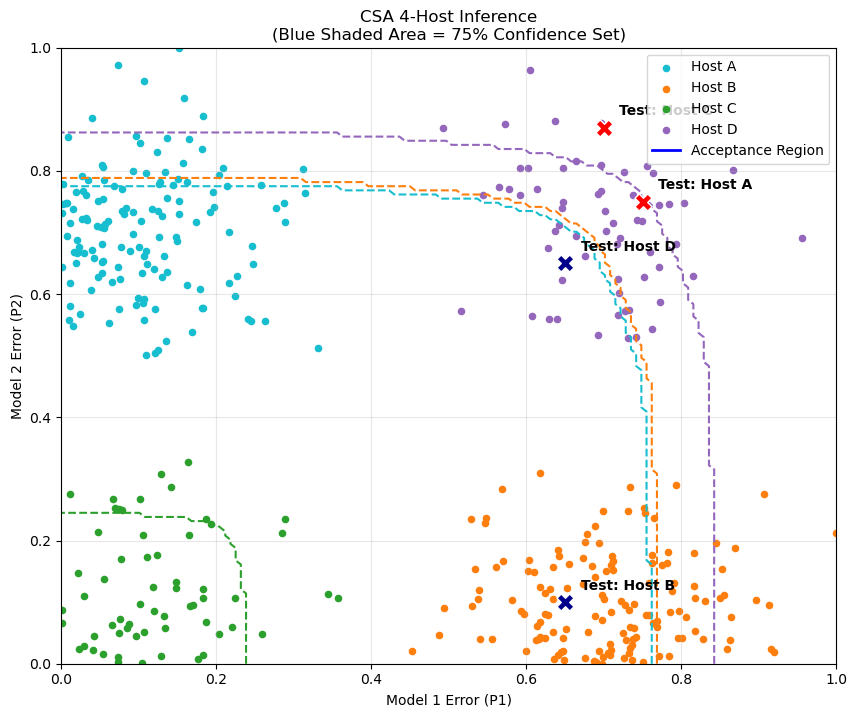

Prediction Set: ['Host B', 'Host D']


In [11]:
# Getting the Prediction Set
prediction_set = get_prediction_set(new_phage_test_scores, u_dirs, q_template, t_hats_dict)

# Visualizing the Result
plot_4_host_inference(raw_scores, labels, u_dirs, q_template, t_hats_dict, new_phage_test_scores, prediction_set, alpha)

print(f"Prediction Set: {[ ['Host A', 'Host B', 'Host C', 'Host D'][i] for i in prediction_set]}")

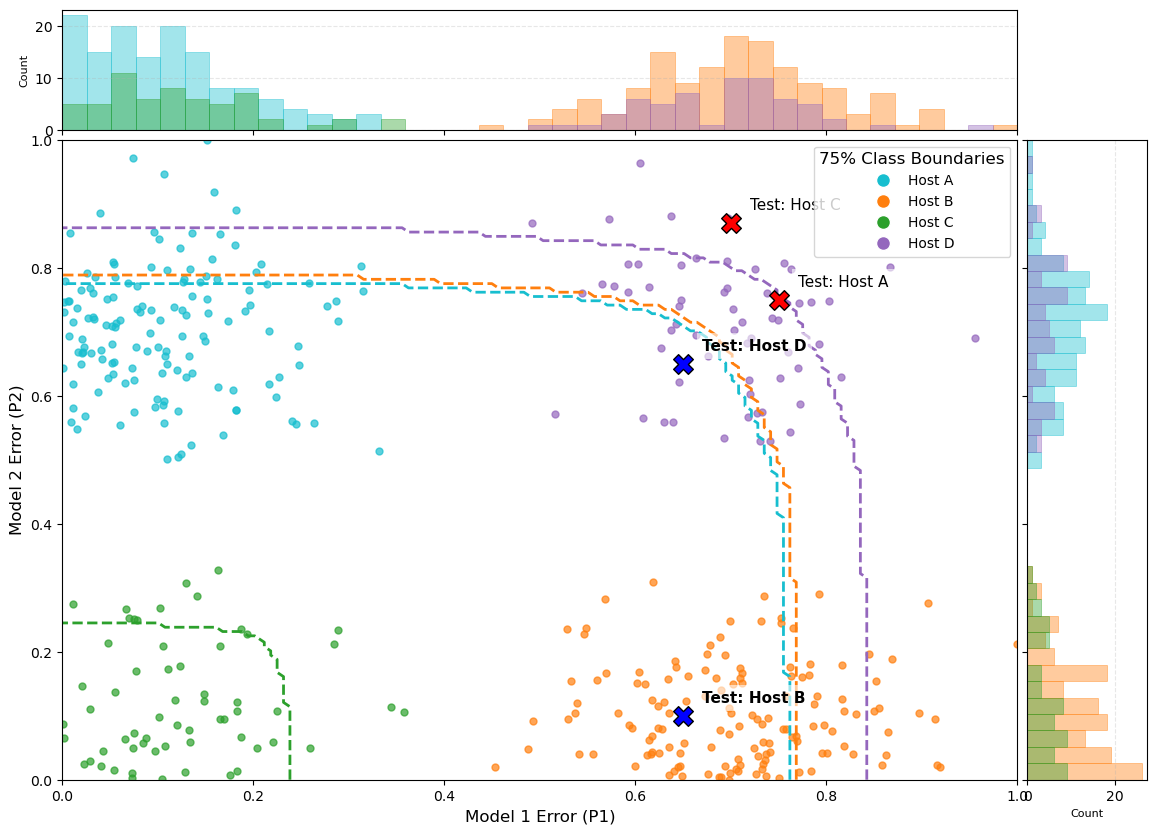

In [12]:
plot_4_host_inference_hist(raw_scores, labels, u_dirs, q_template, t_hats_dict, new_phage_test_scores, prediction_set, alpha)